In [1]:
import pandas as pd
import sqlite3 

In [ ]:

conexion = sqlite3.connect('sanoyfresco.db')

In [ ]:

df = pd.read_sql_query("SELECT * FROM tickets", conexion)

df

In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4975718 entries, 0 to 4975717
Data columns (total 11 columns):
 #   Column           Dtype  
---  ------           -----  
 0   id_pedido        int64  
 1   id_cliente       int64  
 2   fecha            object 
 3   hora             int64  
 4   id_departamento  int64  
 5   id_seccion       int64  
 6   id_producto      int64  
 7   nombre_producto  object 
 8   precio_unitario  float64
 9   cantidad         int64  
 10  precio_total     float64
dtypes: float64(2), int64(7), object(2)
memory usage: 417.6+ MB


In [ ]:
df['fecha'] = pd.to_datetime(df['fecha'])

In [ ]:
#nos mostrara el id_pedido por producto
df_cesta = df[['id_pedido', 'nombre_producto']]
df_cesta

,id_pedido,nombre_producto
0,1,Pepino Kirby
1,1,Bolsa de Bananas Orgánicas
2,1,Aguacate Hass Orgánico
3,2,Col Rizada Orgánica de Michigan
4,2,Zanahorias
...,...,...
4975713,3421080,Leche Entera Orgánica
4975714,3421080,Racimo de Tomates Orgánicos
4975715,3421080,Cilantro Orgánico
4975716,3421082,Fresas


In [20]:
#Nos agrupa el nombre de productos por id_pedido
df_agrupado = df_cesta.groupby('id_pedido')['nombre_producto'].apply(lambda producto: ','.join(producto))
df_agrupado

id_pedido
1          Pepino Kirby,Bolsa de Bananas Orgánicas,Aguaca...
2                 Col Rizada Orgánica de Michigan,Zanahorias
3                                   Espinacas Baby Orgánicas
5          Bolsa de Bananas Orgánicas,Frambuesas Orgánica...
10         Banana,Cilantro Orgánico,Aguacate Orgánico,Ceb...
                                 ...                        
3421077    Frambuesas Orgánicas,Calabacín Orgánico,Leche ...
3421078                       Manzanas Gala Orgánicas,Banana
3421080    Leche Entera Orgánica,Racimo de Tomates Orgáni...
3421082                                               Fresas
3421083                                               Banana
Name: nombre_producto, Length: 2060188, dtype: object

In [ ]:
#Nos dice si el producto ha sido comprado en ese pedido con 0(no comprado) y 1(comprado)
df_transacciones = df_agrupado.str.get_dummies(sep= ',')
df_transacciones

,Agua con Gas de Pomelo,Aguacate Hass Orgánico,Aguacate Orgánico,Ajo Orgánico,Apio Orgánico en Ramillete Pequeño,Arándanos Orgánicos,Banana,Bolsa de Bananas Orgánicas,Calabacín Orgánico,Cebolla Amarilla Orgánica,...,Manzana Honeycrisp Orgánica,Manzanas Gala Orgánicas,Pepino Kirby,Pepino Orgánico,Racimo de Tomates Orgánicos,Rúcula Baby Orgánica,Tomates Cherry Orgánicos,Uvas Rojas sin Semillas,Zanahorias,Zanahorias Baby Orgánicas
id_pedido,,,,,,,,,,,,,,,,,,,,,
1,0,1,0,0,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
10,0,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3421077,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3421078,0,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3421080,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [ ]:
#soporte para cada producto porcentaje de presencia de c columna, osea de las bananas hay un 23% del total de las compras por cliente
#ascending(false) orden desc
soporte = df_transacciones.mean() *100
soporte.sort_values(ascending=False)

Banana                                23.809381
Bolsa de Bananas Orgánicas            19.129710
Fresas Orgánicas                      13.349170
Espinacas Baby Orgánicas              12.198935
Aguacate Hass Orgánico                10.703004
Aguacate Orgánico                      8.929331
Limón Grande                           7.791279
Fresas                                 7.241960
Limones                                7.107944
Leche Entera Orgánica                  6.918301
Frambuesas Orgánicas                   6.906797
Cebolla Amarilla Orgánica              5.706324
Ajo Orgánico                           5.521778
Calabacín Orgánico                     5.302429
Arándanos Orgánicos                    5.086138
Pepino Kirby                           4.840044
Manzana Fuji Orgánica                  4.502841
Limón Orgánico                         4.422266
Tomates Cherry Orgánicos               4.266795
Manzana Honeycrisp Orgánica            4.231216
Uvas Rojas sin Semillas                4

In [ ]:
#funcion para calcular la confianza entre 2 productos de la muestra
#ej si se compra leche(antecedente) entonces se compra pan(consecuente)
#len, obtiene la longitud de los objetos
def confianza(antecedente, consecuente):
    #casos donde se compraron ambos
    conjunto_ac = df_transacciones[(df_transacciones[antecedente] == 1) &
                                   (df_transacciones[consecuente] == 1)]
    #Confianza = compras conjuntas / compras de producto a

    return len(conjunto_ac) /df_transacciones[antecedente].sum()


In [38]:
def lift(antecendente, consecuente):
    soport_a = df_transacciones[antecendente].mean()
    soport_c = df_transacciones[consecuente].mean()

    prob = soport_a * soport_c
    #casos donde se compraron ambos
    conteo_ac = df_transacciones[(df_transacciones[antecendente] == 1) &
                                   (df_transacciones[consecuente] == 1)]
    
    soporte_ac = len(conteo_ac)/len(df_transacciones)
    return soporte_ac  /prob

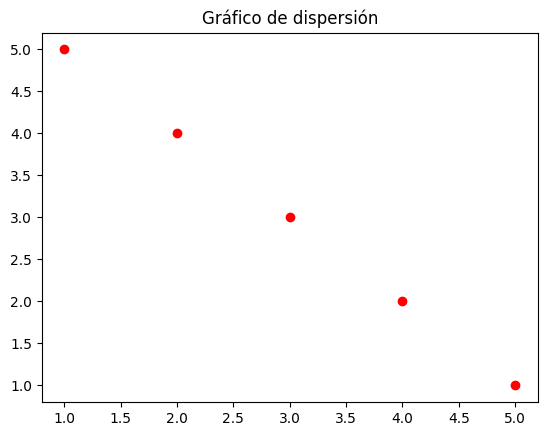

In [1]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5]
y = [5, 4, 3, 2, 1]

plt.scatter(x, y, color='red')
plt.title("Gráfico de dispersión")
plt.show()


In [39]:
from itertools  import combinations

#Definir umbral para la confianza minima

umbral_confianza = 0.05

#crear una lista
asociaciones = []

for antecedente, consecuente in combinations(df_transacciones.columns,2):

    #soporte del antecedente

    soporte_a = df_transacciones[antecedente].mean()

    #calcular la confianza

    conf = confianza(antecedente, consecuente)
    if conf > umbral_confianza:
        asociaciones.append ({
            'antecedente': antecedente,
            'consecuente': consecuente,
            'soporte_a': round(soporte_a * 100,1),
            'confianza': round(conf * 100, 1),
            'lift': round(lift(antecedente, consecuente),1)
        })

#convertir las asociaciones(lista) a un dataframe

df_asoaciacion = pd.DataFrame(asociaciones)

#ordenar las asociaciones por confianza de mayor a menor

df_asoaciacion.sort_values(by = 'lift', ascending=False, inplace=True)

df_asoaciacion

,antecedente,consecuente,soporte_a,confianza,lift
185,Cebolla Roja Orgánica,Cilantro Orgánico,3.4,12.8,3.6
224,Cilantro Orgánico,Limones,3.5,25.4,3.6
61,Ajo Orgánico,Cebolla Amarilla Orgánica,5.5,20.1,3.5
106,Apio Orgánico en Ramillete Pequeño,Zanahorias,3.4,12.0,3.3
102,Apio Orgánico en Ramillete Pequeño,Pepino Orgánico,3.4,12.7,3.1
...,...,...,...,...,...
136,Bolsa de Bananas Orgánicas,Limón Grande,19.1,5.2,0.7
38,Aguacate Orgánico,Bolsa de Bananas Orgánicas,8.9,13.0,0.7
58,Ajo Orgánico,Banana,5.5,17.4,0.7
3,Agua con Gas de Pomelo,Bolsa de Bananas Orgánicas,3.8,13.2,0.7


In [40]:
#crear una tabla con los productos unicos y las columnas correspondientes

productos_unicos = df[['id_producto', 'id_seccion', 'id_departamento', 'nombre_producto']].drop_duplicates()

productos_unicos

,id_producto,id_seccion,id_departamento,nombre_producto
0,49683,83,4,Pepino Kirby
1,13176,24,4,Bolsa de Bananas Orgánicas
2,47209,24,4,Aguacate Hass Orgánico
3,28985,83,4,Col Rizada Orgánica de Michigan
4,17794,83,4,Zanahorias
5,21903,123,4,Espinacas Baby Orgánicas
7,27966,123,4,Frambuesas Orgánicas
9,24852,24,4,Banana
10,31717,16,4,Cilantro Orgánico
11,47766,24,4,Aguacate Orgánico


In [ ]:
df_asociaciones_enriquecido = df_asoaciacion.merge(productos_unicos, left_on='antecedente', right_on='nombre_producto', how='left').drop(columns=['nombre_producto'])
df_asociaciones_enriquecido.columns = ['antecedente', 'consecuente', 'soporte_a', 'confianza', 'lift', 'id_producto_a', 'id_seccion_a', 'id_departamento_a']
df_asociaciones_enriquecido

,antecedente,consecuente,soporte_a,confianza,lift,id_producto_a,id_seccion_a,id_departamento_a
0,Cebolla Roja Orgánica,Cilantro Orgánico,3.4,12.8,3.6,8518,83,4
1,Cilantro Orgánico,Limones,3.5,25.4,3.6,31717,16,4
2,Ajo Orgánico,Cebolla Amarilla Orgánica,5.5,20.1,3.5,24964,83,4
3,Apio Orgánico en Ramillete Pequeño,Zanahorias,3.4,12.0,3.3,44359,83,4
4,Apio Orgánico en Ramillete Pequeño,Pepino Orgánico,3.4,12.7,3.1,44359,83,4
...,...,...,...,...,...,...,...,...
394,Bolsa de Bananas Orgánicas,Limón Grande,19.1,5.2,0.7,13176,24,4
395,Aguacate Orgánico,Bolsa de Bananas Orgánicas,8.9,13.0,0.7,47766,24,4
396,Ajo Orgánico,Banana,5.5,17.4,0.7,24964,83,4
397,Agua con Gas de Pomelo,Bolsa de Bananas Orgánicas,3.8,13.2,0.7,44632,115,7


In [44]:
df_asociaciones_enriquecido.to_csv('reglas.csv', index=False, sep=';', decimal=',')

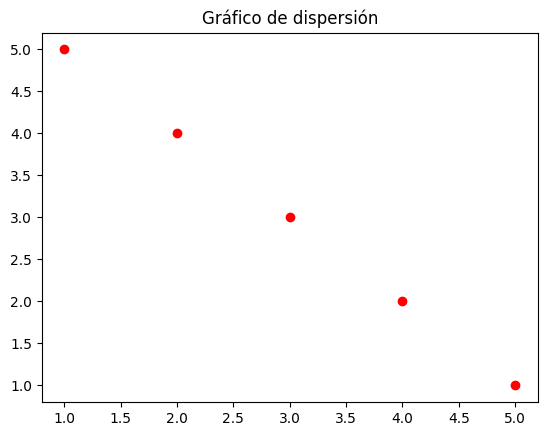

In [2]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5]
y = [5, 4, 3, 2, 1]

plt.scatter(x, y, color='red')
plt.title("Gráfico de dispersión")
plt.show()
